# Credit Card Default Prediction
**MSc Artificial Intelligence – Introduction to AI – Practical skills assessment**

The aim is to predict whether a credit card client will default next month using `Credit_Card.csv`.

**Sections**
1. Setup and loading the data
2. Cleaning
3. New features
4. Task 1 – Exploratory data analysis
5. Task 2 – Data preparation
6. Task 3 – Model training
7. Task 4 – Evaluation, tuning and interpretation
8. Task 5 – Conclusion and future work

## 1. Setup and loading the data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")   # hides convergence/future warnings so the output is easier to read

pd.set_option("display.max_columns", 40)
TARGET = "default.payment.next.month"

In [2]:
# the csv should be in data/, but I also check the notebook folder
path = "data/Credit_Card.csv"
if not os.path.exists(path):
    path = "Credit_Card.csv"

df = pd.read_csv(path, sep=";", low_memory=False)   # the file uses ; as separator

print("File:", path)
print("Shape:", df.shape)
df.head()

File: data/Credit_Card.csv
Shape: (34788, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34788 entries, 0 to 34787
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          34788 non-null  int64  
 1   LIMIT_BAL                   33079 non-null  float64
 2   SEX                         33021 non-null  float64
 3   EDUCATION                   33054 non-null  float64
 4   MARRIAGE                    33055 non-null  float64
 5   AGE                         33033 non-null  float64
 6   PAY_0                       34788 non-null  int64  
 7   PAY_2                       34788 non-null  int64  
 8   PAY_3                       34788 non-null  int64  
 9   PAY_4                       34788 non-null  int64  
 10  PAY_5                       34788 non-null  int64  
 11  PAY_6                       34788 non-null  int64  
 12  BILL_AMT1                   34788 non-null  float64
 13  BILL_AMT2                   347

The shape matches the brief (34,788 rows, 30 columns). Two things stand out in `info()`: `risk_leak` and `LIMIT_BAL_LOG` were read as text instead of numbers, and several columns have fewer non-null values than rows, so there are missing values.

In [4]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print()
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate IDs:", df["ID"].duplicated().sum())

Missing values per column:
LIMIT_BAL        1709
SEX              1767
EDUCATION        1734
MARRIAGE         1733
AGE              1755
PAY_AMT1         1725
PAY_AMT2         1744
LIMIT_BAL_LOG    1709
dtype: int64

Exact duplicate rows: 4788
Duplicate IDs: 4788


## 2. Cleaning
I only changed things where the data showed a clear problem.

**Duplicates** – the duplicate IDs are all exact copies of other rows. I removed them, otherwise the same client could end up in both the training and test set.

In [5]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Rows before:", rows_before, "-> after:", len(df))

Rows before: 34788 -> after: 30000


**risk_leak** – most values look normal (e.g. `0.0703`), but some look like `1.075.675.276.433.290`. These all start with 1, and the normal values never go above 1, so it looks like values of 1 or more lost their decimal point when the file was saved (the brief says the score goes up to about 1.40). I put the decimal point back after the first digit. A few values look like `-2,00E+11`, which are way out of range and can't be recovered, so they become missing.

In [6]:
text = df["risk_leak"].astype(str)
broken = text.str.count(r"\.") > 1
print("Values with several dots:", broken.sum(), "| values with a comma:", text.str.contains(",").sum())

fixed = pd.to_numeric(text, errors="coerce")          # normal numbers convert fine, the rest become NaN
digits = text[broken].str.replace(".", "", regex=False)
fixed[broken] = (digits.str[0] + "." + digits.str[1:]).astype(float)
df["risk_leak"] = fixed

print("risk_leak range now:", round(df["risk_leak"].min(), 3), "to", round(df["risk_leak"].max(), 3))
print("Missing risk_leak:", df["risk_leak"].isna().sum())

Values with several dots: 3345 | values with a comma: 26
risk_leak range now: -0.385 to 1.396
Missing risk_leak: 26


**LIMIT_BAL** – in the original data the highest credit limit is 1,000,000 (Yeh and Lien, 2009), but some rows here go up to several million. `LIMIT_BAL_LOG` has the same dot problem as risk_leak, but its digits are still readable, and for these rows they match log(LIMIT_BAL / 10). So I think these limits were saved ten times too large, and I divide them by 10. After that I rebuild `LIMIT_BAL_LOG` from the fixed column (only for positive values, so the log works).

In [7]:
high = df["LIMIT_BAL"] > 1_000_000
print("LIMIT_BAL above 1,000,000:", high.sum())

# compare the first 4 digits of the stored log with log(LIMIT_BAL / 10)
stored = df.loc[high, "LIMIT_BAL_LOG"].str.replace(".", "", regex=False).str[:4]
expected = np.log(df.loc[high, "LIMIT_BAL"] / 10).map(lambda v: f"{v:.4f}".replace(".", "")[:4])
print("Rows where the stored log matches LIMIT_BAL / 10:", (stored == expected).sum())

df.loc[high, "LIMIT_BAL"] = df.loc[high, "LIMIT_BAL"] / 10
df["LIMIT_BAL_LOG"] = np.log(df["LIMIT_BAL"].where(df["LIMIT_BAL"] > 0))
print("Max LIMIT_BAL now:", df["LIMIT_BAL"].max())

LIMIT_BAL above 1,000,000: 179
Rows where the stored log matches LIMIT_BAL / 10: 179
Max LIMIT_BAL now: 1000000.0


**BILL_AMT_SUM** – should be the sum of the six bills. Some rows were 10 times too big, so I just recalculated it.

In [8]:
bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
wrong = ~np.isclose(df["BILL_AMT_SUM"], df[bill_cols].sum(axis=1))
print("Rows where BILL_AMT_SUM was wrong:", wrong.sum())
df["BILL_AMT_SUM"] = df[bill_cols].sum(axis=1)

Rows where BILL_AMT_SUM was wrong: 291


**Category codes** – EDUCATION has codes 0, 5 and 6 and MARRIAGE has 0, which aren't explained in the data description (except that 4–6 mean "other"). I put them all into "Other" and changed the codes to names so the plots are easier to read. Negative bill amounts I left as they are, since a client can have credit on the account.

In [9]:
df["SEX"] = df["SEX"].map({1: "Male", 2: "Female"})
df["EDUCATION"] = df["EDUCATION"].map({1: "Graduate school", 2: "University", 3: "High school",
                                       0: "Other", 4: "Other", 5: "Other", 6: "Other"})
df["MARRIAGE"] = df["MARRIAGE"].map({1: "Married", 2: "Single", 0: "Other", 3: "Other"})
df["RISK_RATING"] = df["RISK_RATING"].map({1: "1 Low", 2: "2 Medium", 3: "3 High"})

print(df["EDUCATION"].value_counts(dropna=False))

EDUCATION
University         13343
Graduate school    10031
High school         4678
NaN                 1500
Other                448
Name: count, dtype: int64


## 3. New features
I added four simple features:
- `AVG_BILL` – average of the six bills
- `AVG_PAYMENT` – average of the six payments (uses the months that aren't missing)
- `PAYMENT_TO_BILL` – how much of the bill was paid on average. If the average bill is 0 or negative I left it empty, and I capped it at 2 because tiny bills give huge ratios.
- `LATE_COUNT` – in how many of the six months the payment was late (PAY value above 0). Repeated late payments seemed like an obvious thing to check.

In [10]:
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]

df["AVG_BILL"] = df[bill_cols].mean(axis=1)
df["AVG_PAYMENT"] = df[pay_amt_cols].mean(axis=1)
df["PAYMENT_TO_BILL"] = (df["AVG_PAYMENT"] / df["AVG_BILL"]).where(df["AVG_BILL"] > 0).clip(upper=2)
df["LATE_COUNT"] = (df[pay_cols] > 0).sum(axis=1)

# default rate for each number of late months
df.groupby("LATE_COUNT")[TARGET].agg(["count", "mean"]).round(3)

,count,mean
LATE_COUNT,,
0,19931,0.117
1,4426,0.298
2,1899,0.388
3,1154,0.509
4,951,0.573
5,298,0.574
6,1341,0.703


The default rate goes up quite steadily with the number of late months, so `LATE_COUNT` looks useful.

Note: `AVG_BILL` is just `BILL_AMT_SUM / 6`, so I only use it in the EDA and keep `BILL_AMT_SUM` for the models.

## 4. Task 1 – Exploratory data analysis

### 4.1 Target variable

default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    77.9
1    22.1
Name: proportion, dtype: float64


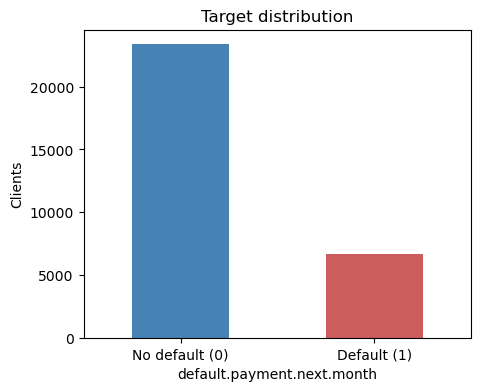

In [11]:
counts = df[TARGET].value_counts()
print(counts)
print((df[TARGET].value_counts(normalize=True) * 100).round(1))

counts.plot(kind="bar", color=["steelblue", "indianred"], figsize=(5, 4))
plt.xticks([0, 1], ["No default (0)", "Default (1)"], rotation=0)
plt.title("Target distribution")
plt.ylabel("Clients")
plt.show()

About 78% of clients did not default and 22% did, so the classes are imbalanced (roughly 3.5 to 1). A model that always says "no default" would already get about 78% accuracy while catching zero defaulters, so accuracy on its own is not a good measure here. I mainly use F1 and recall, and ROC-AUC.

### 4.2 Summary statistics

In [12]:
key_cols = ["LIMIT_BAL", "AGE", "BILL_AMT_SUM", "LIMIT_BAL_LOG", "risk_leak"]
summary = df[key_cols].agg(["mean", "median", "std", "min", "max", "skew"]).T
summary.round(2)

,mean,median,std,min,max,skew
LIMIT_BAL,169642.80,140000.00,133187.31,10000.00,1000000.00,1.14
AGE,35.50,34.00,9.22,21.00,79.00,0.73
BILL_AMT_SUM,269861.67,126311.00,379564.33,-336259.00,5263883.00,2.73
LIMIT_BAL_LOG,11.67,11.85,0.94,9.21,13.82,-0.51
risk_leak,0.22,0.04,0.43,-0.39,1.40,1.23


For `LIMIT_BAL` and especially `BILL_AMT_SUM` the mean is much higher than the median and the skew is positive, so a small number of clients have very large values. `LIMIT_BAL_LOG` is much less skewed, which is the point of taking the log. `risk_leak` also has a mean well above its median.

### 4.3 Histograms and box plots

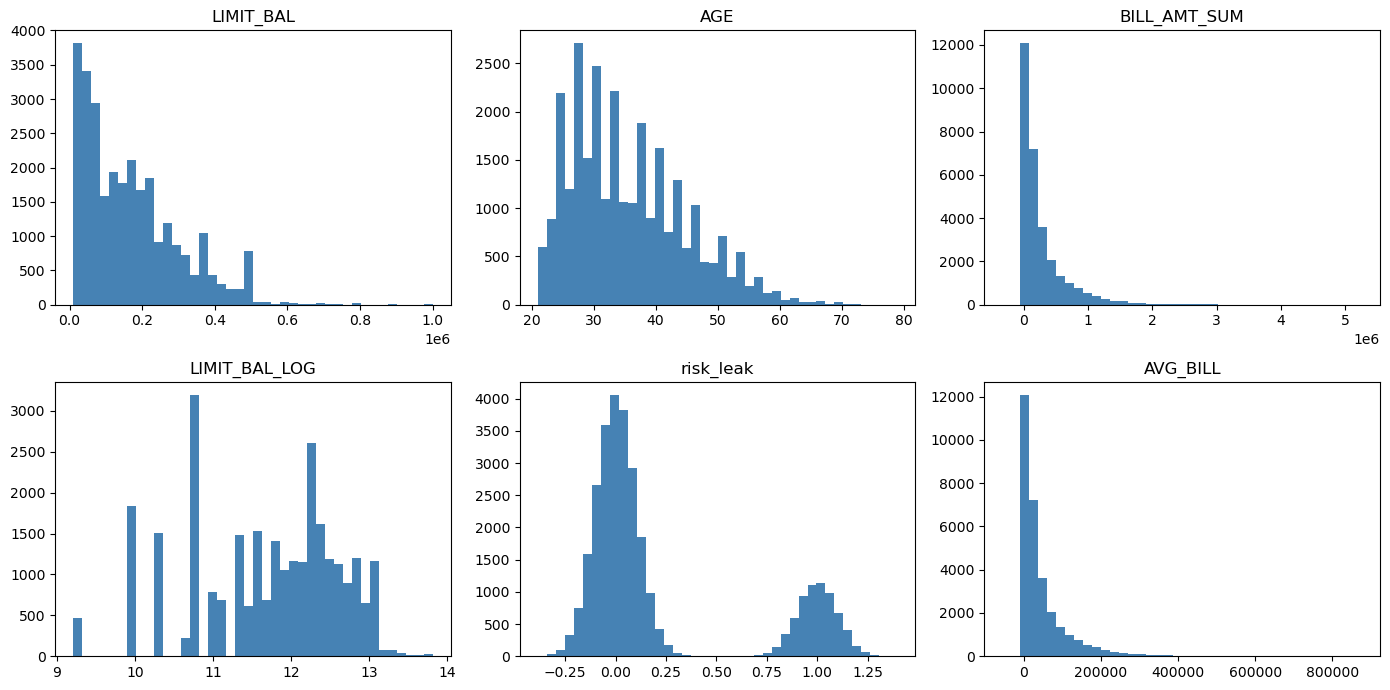

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, key_cols + ["AVG_BILL"]):
    ax.hist(df[col].dropna(), bins=40, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

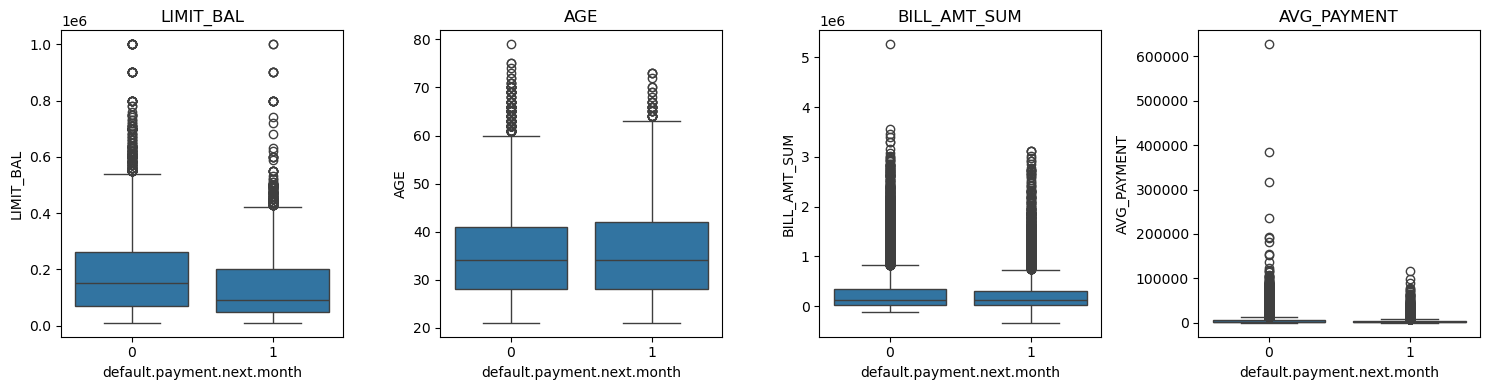

,LIMIT_BAL,AGE,BILL_AMT_SUM,AVG_PAYMENT
default.payment.next.month,,,,
0,150000.0,34.0,128660.5,2741.333333
1,90000.0,34.0,118688.0,1600.250000


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, ["LIMIT_BAL", "AGE", "BILL_AMT_SUM", "AVG_PAYMENT"]):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

df.groupby(TARGET)[["LIMIT_BAL", "AGE", "BILL_AMT_SUM", "AVG_PAYMENT"]].median()

The money columns have a lot of outliers (the dots above the boxes). I kept them because big limits and bills are normal for some clients. Defaulters have a clearly lower median credit limit and lower average payments, while age and total bill look fairly similar between the two groups.

### 4.4 Categorical variables

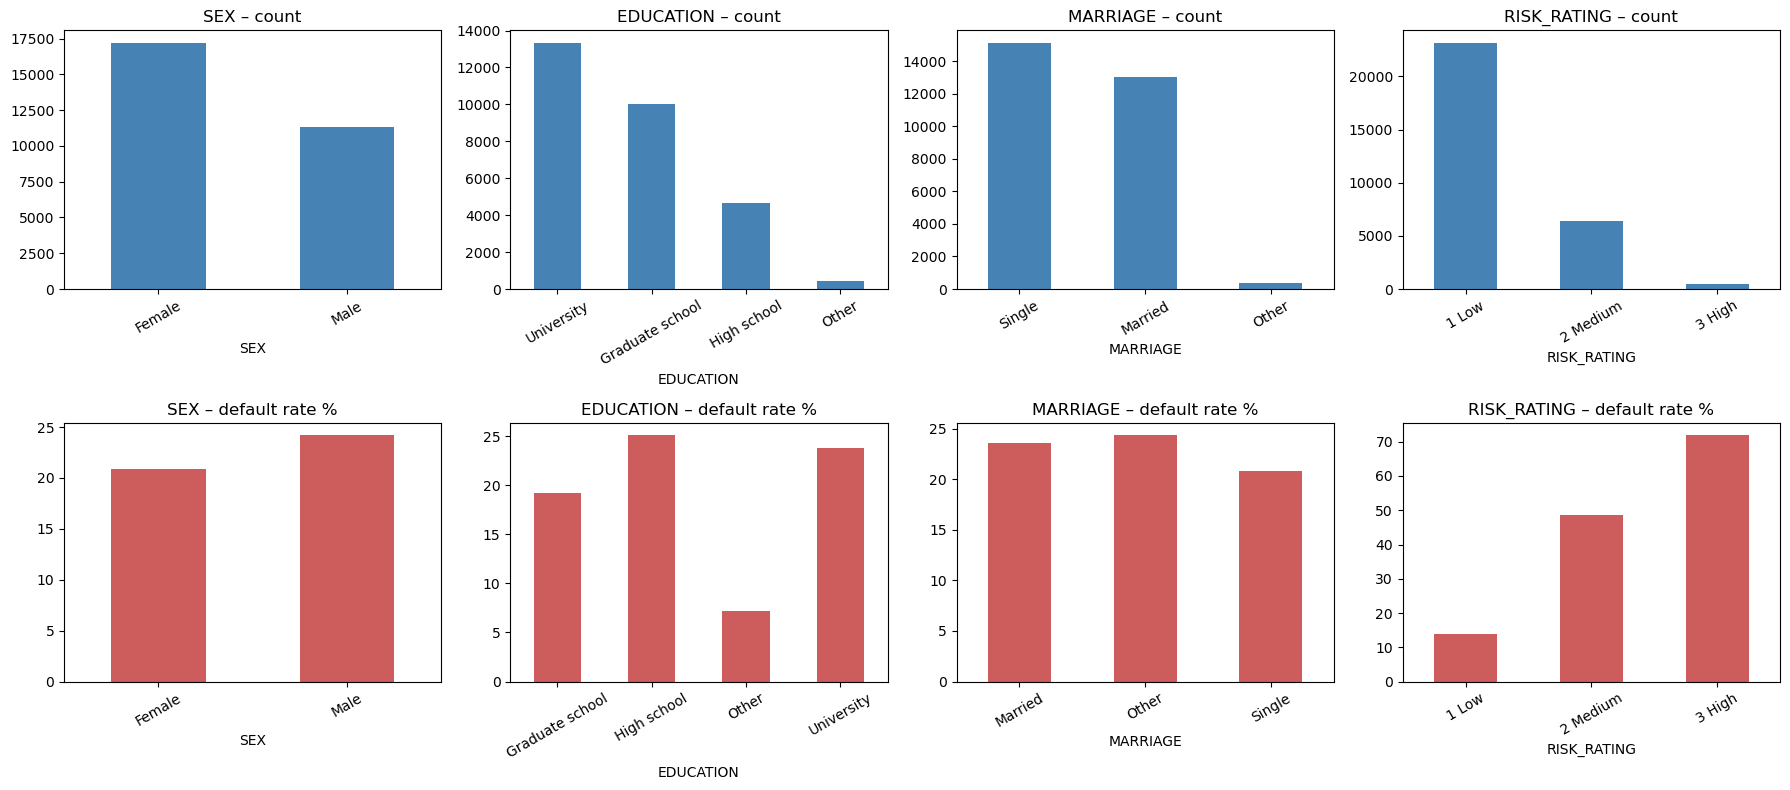

In [15]:
cat_cols = ["SEX", "EDUCATION", "MARRIAGE", "RISK_RATING"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind="bar", ax=axes[0, i], color="steelblue", title=f"{col} – count")
    (df.groupby(col)[TARGET].mean() * 100).plot(kind="bar", ax=axes[1, i], color="indianred",
                                                title=f"{col} – default rate %")
    axes[0, i].tick_params(axis="x", rotation=30)
    axes[1, i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [16]:
for col in cat_cols:
    print((df.groupby(col)[TARGET].mean() * 100).round(1), "\n")

SEX
Female    20.9
Male      24.2
Name: default.payment.next.month, dtype: float64 

EDUCATION
Graduate school    19.2
High school        25.1
Other               7.1
University         23.8
Name: default.payment.next.month, dtype: float64 

MARRIAGE
Married    23.6
Other      24.4
Single     20.8
Name: default.payment.next.month, dtype: float64 

RISK_RATING
1 Low       13.8
2 Medium    48.7
3 High      71.9
Name: default.payment.next.month, dtype: float64 



- **SEX, EDUCATION, MARRIAGE:** the default rates differ by only a few percentage points between most groups (males are slightly higher than females, for example). EDUCATION "Other" is lower, but it is a small group.
- **RISK_RATING:** this is the big one. The default rate rises from about 14% for "Low" to about 49% for "Medium" and 72% for "High". It is clearly linked to default, but it isn't explained how the bank created this rating, so I keep that in mind.

### 4.5 CITY
There are 50 cities, so I looked at the counts, the default rate in the most common cities, and a chi-square test.

Number of cities: 50
Smallest / largest city: 548 / 662


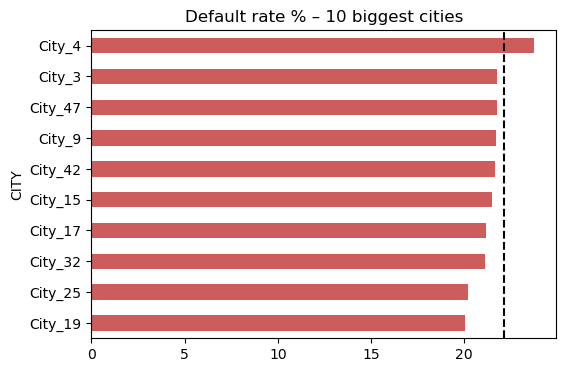

Chi-square = 52.5, dof = 49, p-value = 0.339, Cramér's V = 0.042


In [17]:
city_counts = df["CITY"].value_counts()
print("Number of cities:", len(city_counts))
print("Smallest / largest city:", city_counts.min(), "/", city_counts.max())

top10 = city_counts.head(10).index
city_rate = df[df["CITY"].isin(top10)].groupby("CITY")[TARGET].mean() * 100
city_rate.sort_values().plot(kind="barh", color="indianred", figsize=(6, 4), title="Default rate % – 10 biggest cities")
plt.axvline(df[TARGET].mean() * 100, color="black", linestyle="--")
plt.show()

chi2, p, dof, _ = chi2_contingency(pd.crosstab(df["CITY"], df[TARGET]))
cramers_v = np.sqrt(chi2 / len(df))
print(f"Chi-square = {chi2:.1f}, dof = {dof}, p-value = {p:.3f}, Cramér's V = {cramers_v:.3f}")

The cities are all about the same size and their default rates are close to the overall rate (dashed line). The chi-square p-value is well above 0.05 and Cramér's V is very small, so this sample does not show a significant association between city and default. That doesn't prove city has no effect at all, but it probably won't help the models much.

### 4.6 Payment history (PAY_0 to PAY_6)
The PAY columns are status codes: -2 = no use, -1 = paid in full, 0 = minimum payment, 1–8 = months late.

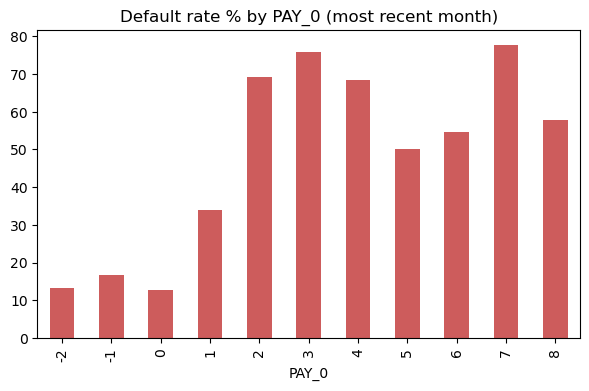

PAY_0    0.325
PAY_2    0.264
PAY_3    0.235
PAY_4    0.217
PAY_5    0.204
PAY_6    0.187
dtype: float64

In [18]:
(df.groupby("PAY_0")[TARGET].mean() * 100).plot(kind="bar", color="indianred", figsize=(7, 4),
                                                 title="Default rate % by PAY_0 (most recent month)")
plt.show()

df[pay_cols].corrwith(df[TARGET]).round(3)

Once `PAY_0` shows 2 or more months late, over half of the clients default. The correlation with the target is highest for `PAY_0` and goes down month by month to `PAY_6`, so the most recent payment behaviour matters most.

### 4.7 Correlation with the target
I only put real numerical columns in the Pearson correlation. SEX, EDUCATION, MARRIAGE, CITY and RISK_RATING are categories so I left them out, and risk_leak is looked at separately in 4.8.

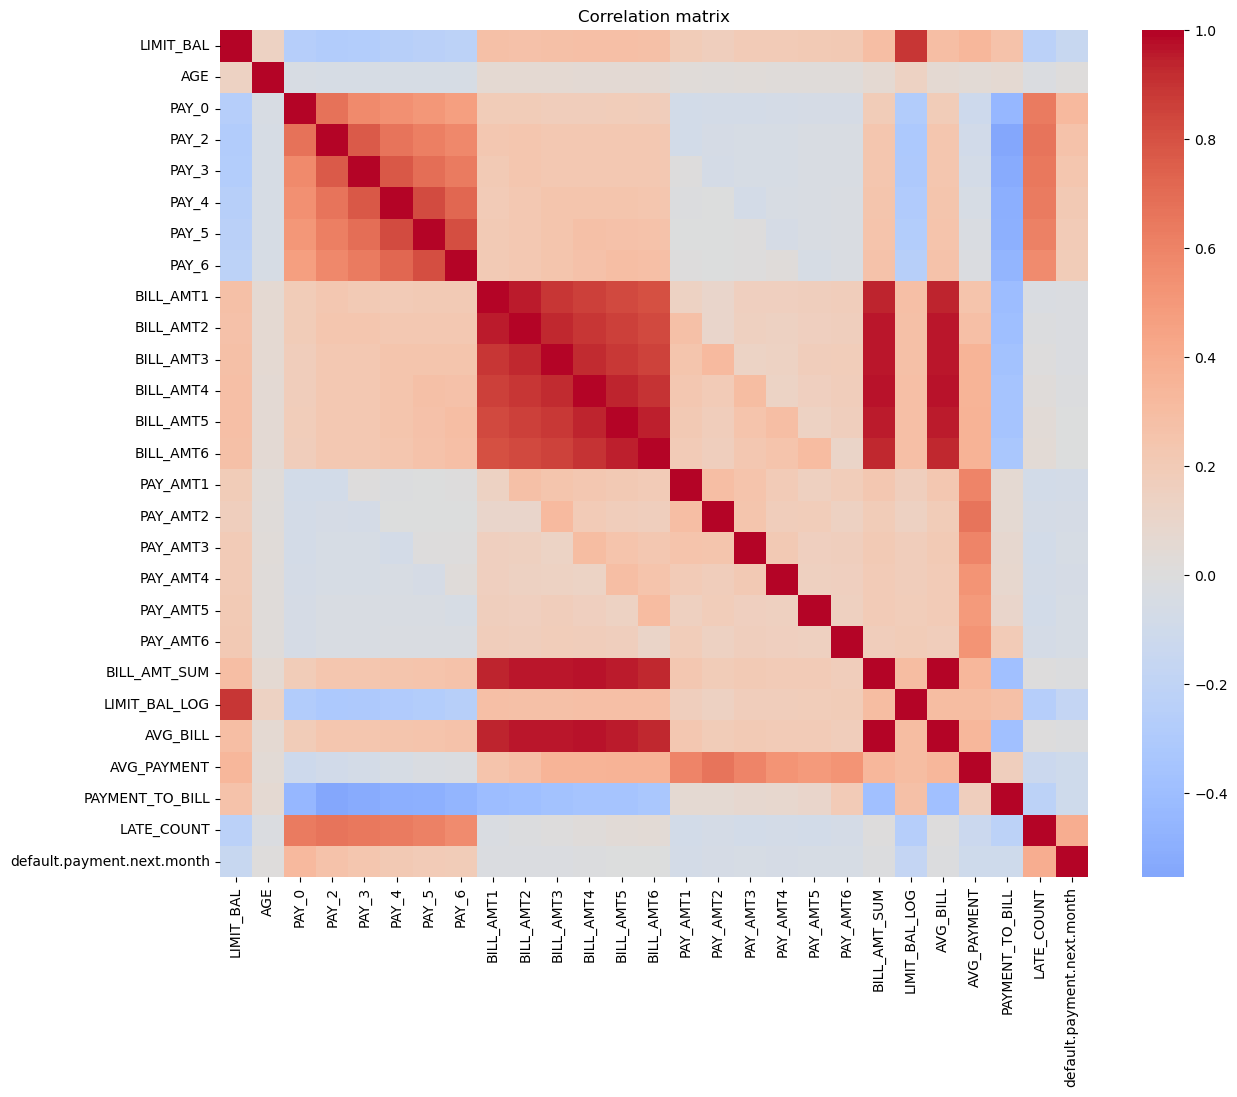

LATE_COUNT         0.398
PAY_0              0.325
PAY_2              0.264
PAY_3              0.235
PAY_4              0.217
PAY_5              0.204
PAY_6              0.187
LIMIT_BAL_LOG     -0.173
LIMIT_BAL         -0.149
PAYMENT_TO_BILL   -0.106
Name: default.payment.next.month, dtype: float64

In [19]:
num_cols = (["LIMIT_BAL", "AGE"] + pay_cols + bill_cols + pay_amt_cols +
            ["BILL_AMT_SUM", "LIMIT_BAL_LOG", "AVG_BILL", "AVG_PAYMENT", "PAYMENT_TO_BILL", "LATE_COUNT", TARGET])
corr = df[num_cols].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).head(10).round(3)

The strongest correlations with default are `LATE_COUNT` and the PAY columns (positive), then the credit limit (negative – higher limit, less default). The bill amounts barely correlate with the target, but they are very strongly correlated with each other (the red block in the heatmap).

### 4.8 risk_leak
The name already suggests this column might "leak" the answer, so I checked it before deciding what to do.

                              count  mean    std    min    25%    50%    75%  \
default.payment.next.month                                                     
0                           23338.0  -0.0  0.101 -0.385 -0.069 -0.001  0.067   
1                            6636.0   1.0  0.099  0.644  0.933  1.001  1.067   

                              max  
default.payment.next.month         
0                           0.430  
1                           1.396  

ROC-AUC of risk_leak on its own: 1.0
Correlation with target: 0.972


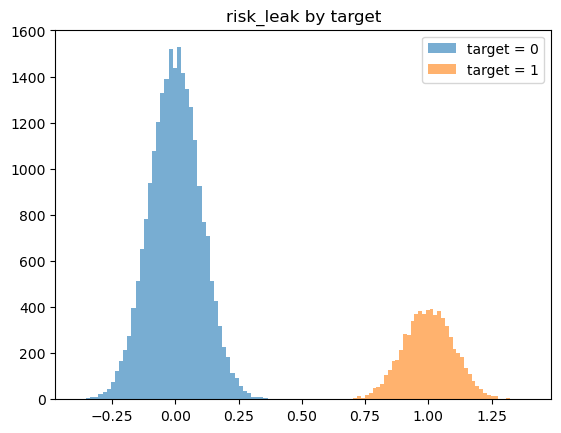

In [20]:
print(df.groupby(TARGET)["risk_leak"].describe().round(3))

ok = df["risk_leak"].notna()
print("\nROC-AUC of risk_leak on its own:", round(roc_auc_score(df.loc[ok, TARGET], df.loc[ok, "risk_leak"]), 3))
print("Correlation with target:", round(df["risk_leak"].corr(df[TARGET]), 3))

for k in [0, 1]:
    plt.hist(df.loc[df[TARGET] == k, "risk_leak"].dropna(), bins=50, alpha=0.6, label=f"target = {k}")
plt.legend()
plt.title("risk_leak by target")
plt.show()

risk_leak separates the two classes almost perfectly: non-defaulters are centred around 0 and defaulters around 1, the ROC-AUC on its own is about 1.0 and the correlation is about 0.97. No real predictor is this good, and I can't confirm this score would be known before the client defaults. So I **don't use risk_leak in the models**. There is a small experiment showing its effect in section 7.6.

**Summary of Task 1:** the features most linked to default are the payment history (PAY_0 most of all, and LATE_COUNT), RISK_RATING and the credit limit. risk_leak is linked even more strongly but looks like leakage.

## 5. Task 2 – Data preparation

### 5.1 Features and train/test split
I split the data before any preprocessing, so things like the median and the scaling are learned only from the training data (otherwise information from the test set leaks in).

I left out `ID` (just a number), `risk_leak` (leakage), `LIMIT_BAL_LOG` (same information as LIMIT_BAL) and `AVG_BILL` (same as BILL_AMT_SUM / 6).

I used an 80/20 split: with 30,000 rows that still leaves 6,000 clients for testing, which is enough to get stable scores, while most of the data is used for training. `stratify=y` keeps the 22% default rate the same in both parts.

In [21]:
num_features = (["LIMIT_BAL", "AGE"] + pay_cols + bill_cols + pay_amt_cols +
                ["BILL_AMT_SUM", "AVG_PAYMENT", "PAYMENT_TO_BILL", "LATE_COUNT"])
cat_features = ["SEX", "EDUCATION", "MARRIAGE", "CITY", "RISK_RATING"]

X = df[num_features + cat_features]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Default rate train: {:.3f}  test: {:.3f}".format(y_train.mean(), y_test.mean()))

Train: (24000, 29)  Test: (6000, 29)
Default rate train: 0.221  test: 0.221


### 5.2 Missing values

In [22]:
missing = pd.DataFrame({"missing": X.isna().sum(), "percent": (X.isna().mean() * 100).round(1)})
missing[missing["missing"] > 0]

,missing,percent
LIMIT_BAL,1500,5.0
AGE,1500,5.0
PAY_AMT1,1500,5.0
PAY_AMT2,1500,5.0
PAYMENT_TO_BILL,1071,3.6
SEX,1500,5.0
EDUCATION,1500,5.0
MARRIAGE,1500,5.0


| Column | Why it is missing | What I did |
|---|---|---|
| LIMIT_BAL, AGE, PAY_AMT1, PAY_AMT2 | missing in the raw file (~5% each) | median of the training data |
| PAYMENT_TO_BILL | average bill was 0 or negative | median of the training data |
| SEX, EDUCATION, MARRIAGE | missing in the raw file (~5% each) | most common value in the training data |

I didn't drop rows because each column is only about 5% missing, but they are spread over different rows, so dropping every row with a gap would remove a lot more clients (around a third). I used the median for numbers because the money columns have big outliers that would pull the mean up.

### 5.3 Encoding and scaling
- Numerical columns: median imputation, then `StandardScaler`. Logistic Regression and KNN are affected by scale (otherwise bill amounts in the hundreds of thousands would dominate age). Trees don't need it but it doesn't hurt.
- Categorical columns: most-frequent imputation, then one-hot encoding. One-hot is better than numbers like 1, 2, 3 because EDUCATION or CITY don't have a real order. All 50 cities have at least 500 clients, so I didn't need to group rare cities.

Everything goes into a `Pipeline` with the model, so it is fitted on the training data only.

In [23]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), num_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

### 5.4 Before and after example

In [24]:
# fit only on the training data, just to show what it does
preprocess.fit(X_train)
X_train_done = pd.DataFrame(preprocess.transform(X_train), columns=preprocess.get_feature_names_out(),
                            index=X_train.index)

# a few rows that have missing values
rows = X_train[X_train["LIMIT_BAL"].isna() | X_train["EDUCATION"].isna()].index[:4]

print("BEFORE")
display(X_train.loc[rows, ["LIMIT_BAL", "AGE", "PAY_AMT1", "EDUCATION"]])
print("AFTER")
edu = [c for c in X_train_done.columns if "EDUCATION" in c]
display(X_train_done.loc[rows, ["num__LIMIT_BAL", "num__AGE", "num__PAY_AMT1"] + edu].round(2))

print("Columns before:", X_train.shape[1], "-> after one-hot encoding:", X_train_done.shape[1])
print("Median LIMIT_BAL used for missing values:", X_train["LIMIT_BAL"].median())

BEFORE


,LIMIT_BAL,AGE,PAY_AMT1,EDUCATION
15091,NaN,32.0,6000.0,Graduate school
173,NaN,24.0,0.0,Graduate school
1092,NaN,29.0,0.0,High school
9999,NaN,36.0,3000.0,University


AFTER


,num__LIMIT_BAL,num__AGE,num__PAY_AMT1,cat__EDUCATION_Graduate school,cat__EDUCATION_High school,cat__EDUCATION_Other,cat__EDUCATION_University
15091,-0.22,-0.38,0.04,1.0,0.0,0.0,0.0
173,-0.22,-1.27,-0.35,1.0,0.0,0.0,0.0
1092,-0.22,-0.71,-0.35,0.0,1.0,0.0,0.0
9999,-0.22,0.07,-0.15,0.0,0.0,0.0,1.0


Columns before: 29 -> after one-hot encoding: 86
Median LIMIT_BAL used for missing values: 140000.0


The missing LIMIT_BAL values were replaced with the training median, so after scaling they all get the same value. The numbers are now on a similar scale (around 0), and EDUCATION became separate 0/1 columns. If EDUCATION is missing, it gets "University", the most common value in the training data.

## 6. Task 3 – Model training

### 6.1 Choice of models
The data has 30,000 rows, a mix of numerical and one-hot columns, and an imbalanced target, so I picked models that train quickly on this size and cover different approaches:

- **Logistic Regression** – a simple baseline, and its output is easy to understand.
- **Gaussian Naive Bayes** – a simple probabilistic model, very fast, to see if a different approach gives similar results.
- **Decision Tree** – easy to inspect, and handles the PAY status codes without needing them to be linear.
- **Extra Trees** – many trees built with extra randomness, which usually overfits less than one tree.
- **Gradient Boosting** – builds small trees one after another, each fixing the previous errors. Good for tabular data like this.
- **KNN** – predicts from the most similar clients. Needs scaled data, which the pipeline gives it.

All of them use their default settings first, with no class balancing (so I can see how they deal with the imbalance on their own). I only set `random_state=42` so the results can be repeated.

In [25]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
}

### 6.2 Initial hyperparameters (before tuning)

In [26]:
for name, model in models.items():
    print(name)
    for param, value in model.get_params().items():
        print("   ", param, "=", value)
    print()

Logistic Regression
    C = 1.0
    class_weight = None
    dual = False
    fit_intercept = True
    intercept_scaling = 1
    l1_ratio = None
    max_iter = 100
    multi_class = deprecated
    n_jobs = None
    penalty = l2
    random_state = 42
    solver = lbfgs
    tol = 0.0001
    verbose = 0
    warm_start = False

Naive Bayes
    priors = None
    var_smoothing = 1e-09

Decision Tree
    ccp_alpha = 0.0
    class_weight = None
    criterion = gini
    max_depth = None
    max_features = None
    max_leaf_nodes = None
    min_impurity_decrease = 0.0
    min_samples_leaf = 1
    min_samples_split = 2
    min_weight_fraction_leaf = 0.0
    monotonic_cst = None
    random_state = 42
    splitter = best

Extra Trees
    bootstrap = False
    ccp_alpha = 0.0
    class_weight = None
    criterion = gini
    max_depth = None
    max_features = sqrt
    max_leaf_nodes = None
    max_samples = None
    min_impurity_decrease = 0.0
    min_samples_leaf = 1
    min_samples_split = 2
    mi

### 6.3 Training

In [27]:
fitted = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(name, "- done")

Logistic Regression - done
Naive Bayes - done
Decision Tree - done
Extra Trees - done
Gradient Boosting - done
KNN - done


## 7. Task 4 – Evaluation, tuning and interpretation

### 7.1 Results of the default models (test set)

In [28]:
def scores(model, X_, y_):
    pred = model.predict(X_)
    prob = model.predict_proba(X_)[:, 1]
    return {"Accuracy": accuracy_score(y_, pred), "Precision": precision_score(y_, pred),
            "Recall": recall_score(y_, pred), "F1": f1_score(y_, pred), "ROC-AUC": roc_auc_score(y_, prob)}

results = pd.DataFrame({name: scores(m, X_test, y_test) for name, m in fitted.items()}).T
results.round(3).sort_values("F1", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC
Naive Bayes,0.723,0.410,0.580,0.480,0.719
Gradient Boosting,0.818,0.663,0.361,0.468,0.779
Extra Trees,0.808,0.616,0.357,0.452,0.744
KNN,0.795,0.556,0.360,0.437,0.706
Logistic Regression,0.808,0.638,0.301,0.409,0.740
Decision Tree,0.729,0.389,0.393,0.391,0.609


Gradient Boosting has the best accuracy, precision and ROC-AUC, but its recall is only about 0.36, so it misses almost two thirds of the defaulters. Naive Bayes has the lowest accuracy but by far the best recall, and it ends up with the highest F1. Logistic Regression has the lowest recall. The single Decision Tree is the weakest overall (lowest ROC-AUC), which fits with it overfitting when it has no depth limit. Most models are only a bit above the 78% "always no default" accuracy, which shows again why accuracy isn't enough here.

### 7.2 Confusion matrices
Top-left = correct "no default", bottom-right = correct "default", bottom-left = defaulters the model missed, top-right = false alarms.

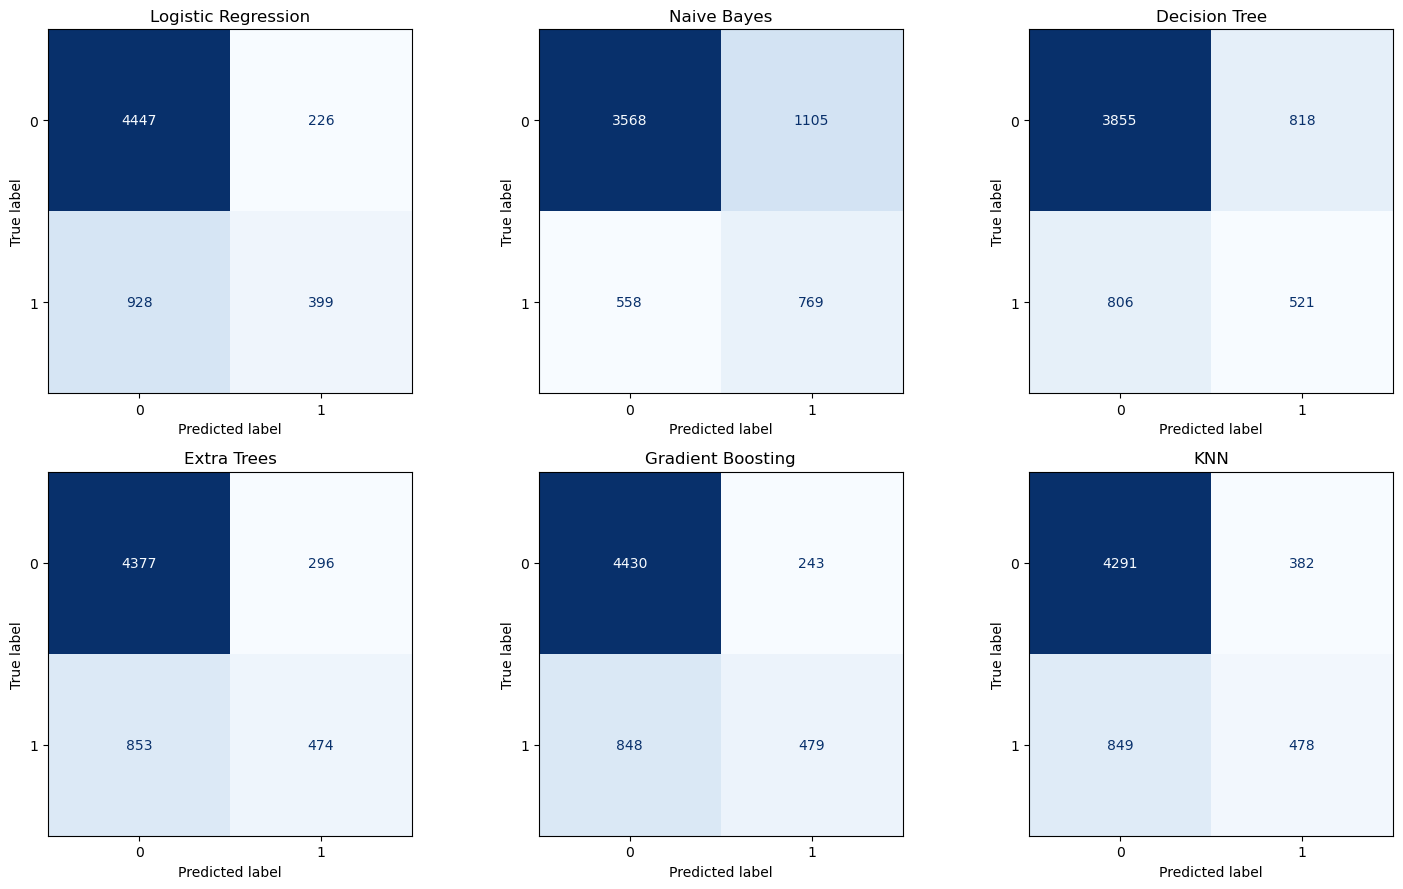

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, m) in zip(axes.flat, fitted.items()):
    ConfusionMatrixDisplay.from_estimator(m, X_test, y_test, ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

The bottom-left cell is the important one for a bank. Naive Bayes misses the fewest defaulters (but has more false alarms), while Logistic Regression misses the most.

### 7.3 ROC curves

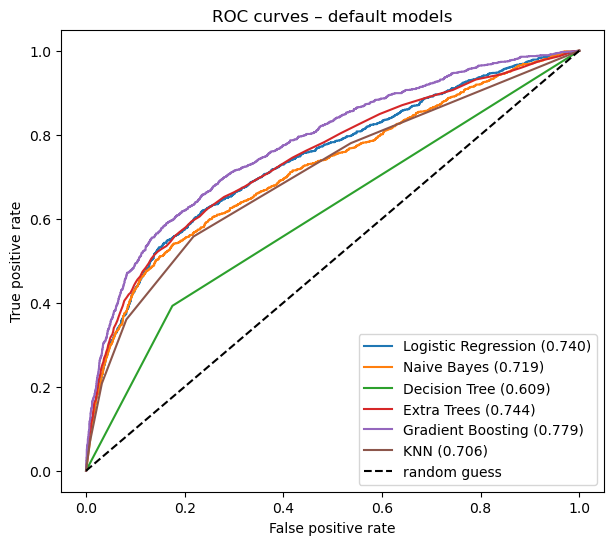

In [30]:
plt.figure(figsize=(7, 6))
for name, m in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    plt.plot(fpr, tpr, label=f"{name} ({results.loc[name, 'ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="random guess")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves – default models")
plt.legend()
plt.show()

Gradient Boosting's curve is the highest, and the Decision Tree's is clearly the lowest. All models are well above the random line.

### 7.4 Choosing models to tune
I didn't want to choose using the test set, because then the test score wouldn't be a fair check any more. with F1 as the score (because of the class imbalance, it balances precision and recall).

In [31]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    f1s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")
    cv_results[name] = [f1s.mean(), f1s.std()]

cv_table = pd.DataFrame(cv_results, index=["mean CV F1", "std"]).T.sort_values("mean CV F1", ascending=False)
cv_table.round(4)

,mean CV F1,std
Naive Bayes,0.4880,0.0140
Gradient Boosting,0.4765,0.0064
Extra Trees,0.4612,0.0106
KNN,0.4355,0.0026
Decision Tree,0.4149,0.0015
Logistic Regression,0.4101,0.0135


The two best by CV F1 are Naive Bayes and Gradient Boosting, the same order as on the test set. I tune these two.

### 7.5 Hyperparameter tuning (GridSearchCV)
I kept the grids small. For Naive Bayes the main setting is `var_smoothing` (how much extra variance is added, which smooths the probabilities). For Gradient Boosting I tried more trees and a smaller learning rate.

In [32]:
grids = {
    "Naive Bayes": {"model__var_smoothing": [1e-9, 1e-6, 1e-3, 1e-2, 1e-1]},
    "Gradient Boosting": {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1]},
}

tuned = {}
for name, grid in grids.items():
    pipe = Pipeline([("prep", preprocess), ("model", models[name])])
    search = GridSearchCV(pipe, grid, cv=cv, scoring="f1")
    search.fit(X_train, y_train)
    tuned[name] = search
    print(name)
    print("   best parameters:", search.best_params_)
    print("   best CV F1: {:.4f}  (default: {:.4f})".format(search.best_score_, cv_table.loc[name, "mean CV F1"]))

Naive Bayes
   best parameters: {'model__var_smoothing': 0.1}
   best CV F1: 0.5272  (default: 0.4880)
Gradient Boosting
   best parameters: {'model__learning_rate': 0.1, 'model__n_estimators': 200}
   best CV F1: 0.4794  (default: 0.4765)


Tuning helped Naive Bayes quite a lot in cross-validation, and Gradient Boosting only very slightly. Tuned Naive Bayes has the higher CV F1, so that is my final model. Now I check it on the test set that hasn't been used for any decisions.

In [33]:
final = tuned["Naive Bayes"].best_estimator_

before_after = pd.DataFrame({
    "NB default": scores(fitted["Naive Bayes"], X_test, y_test),
    "NB tuned": scores(final, X_test, y_test),
    "GB tuned": scores(tuned["Gradient Boosting"].best_estimator_, X_test, y_test),
}).T
before_after.round(3)

,Accuracy,Precision,Recall,F1,ROC-AUC
NB default,0.723,0.410,0.580,0.480,0.719
NB tuned,0.772,0.485,0.546,0.514,0.731
GB tuned,0.817,0.656,0.362,0.466,0.778


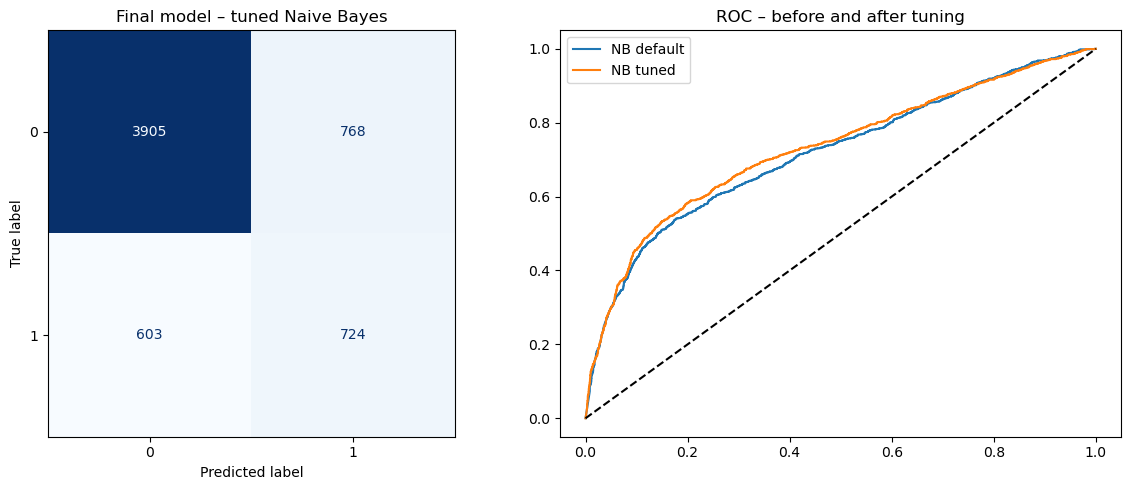

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_estimator(final, X_test, y_test, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Final model – tuned Naive Bayes")

for label, m in [("NB default", fitted["Naive Bayes"]), ("NB tuned", final)]:
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, label=label)
axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_title("ROC – before and after tuning")
axes[1].legend()
plt.tight_layout()
plt.show()

After tuning, Naive Bayes on the test set improved in accuracy, precision, F1 and ROC-AUC, and recall dropped a little (it predicts "default" slightly less often now, so fewer false alarms but a few more misses). It still finds more defaulters than tuned Gradient Boosting, which has a higher ROC-AUC but much lower recall. So which model is "best" depends on the metric – I went with F1 because missing defaulters matters here.

### 7.6 Model interpretation – permutation importance
For interpretation I used permutation importance: shuffle one column in the test data and see how much the ROC-AUC drops. If the score drops a lot, the model depends on that column. I used it on the whole pipeline so CITY or RISK_RATING count as one feature each instead of many one-hot columns. I used 3,000 test rows to keep it quick.

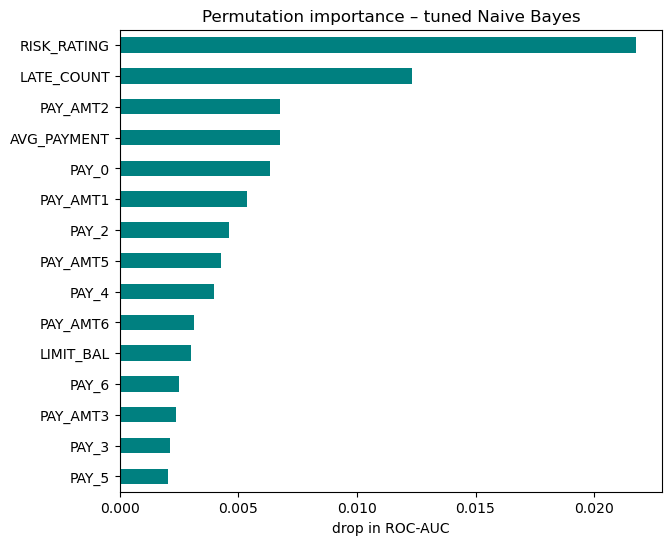

RISK_RATING    0.0218
LATE_COUNT     0.0123
PAY_AMT2       0.0068
AVG_PAYMENT    0.0067
PAY_0          0.0064
PAY_AMT1       0.0054
PAY_2          0.0046
PAY_AMT5       0.0043
PAY_4          0.0040
PAY_AMT6       0.0031
LIMIT_BAL      0.0030
PAY_6          0.0025
PAY_AMT3       0.0024
PAY_3          0.0021
PAY_5          0.0020
dtype: float64

In [35]:
sample = X_test.sample(3000, random_state=42)
perm = permutation_importance(final, sample, y_test.loc[sample.index], scoring="roc_auc",
                              n_repeats=5, random_state=42)

importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

importance.head(15)[::-1].plot(kind="barh", color="teal", figsize=(7, 6))
plt.title("Permutation importance – tuned Naive Bayes")
plt.xlabel("drop in ROC-AUC")
plt.show()

importance.round(4).head(15)

In [36]:
# where do the features from the brief end up?
ranks = importance.rank(ascending=False).astype(int)
for f in ["RISK_RATING", "PAY_0", "LIMIT_BAL", "BILL_AMT_SUM", "LATE_COUNT"]:
    print(f"{f:14s} rank {ranks[f]:2d} of {len(ranks)}   AUC drop = {importance[f]:.4f}")

RISK_RATING    rank  1 of 29   AUC drop = 0.0218
PAY_0          rank  5 of 29   AUC drop = 0.0064
LIMIT_BAL      rank 11 of 29   AUC drop = 0.0030
BILL_AMT_SUM   rank 23 of 29   AUC drop = 0.0001
LATE_COUNT     rank  2 of 29   AUC drop = 0.0123


- **RISK_RATING** is the most important feature for the final model. That fits the EDA (default rate from 14% to 72%), but it also means the model relies a lot on a rating whose origin I don't know. If it was made using information from after the prediction date, it would be a leakage problem like risk_leak.
- **PAY_0** and my **LATE_COUNT** feature are also near the top, so payment history is the main behaviour signal. LATE_COUNT is built from the PAY columns, so they share importance between them.
- **LIMIT_BAL** has a small but real effect (lower limits go with more default).
- **BILL_AMT_SUM** has almost no importance, and the same is true for the individual bill columns. This matches the EDA, where bills hardly correlated with default. Part of this is also because the bill columns overlap so much that shuffling one of them doesn't lose much information.
- **risk_leak** is not in the model on purpose – see below.

### 7.7 risk_leak – what happens if I include it
**This is only a demonstration, not used for the final model.** I trained a Logistic Regression with and without risk_leak, using cross-validation on the training data.

In [37]:
X_train_leak = X_train.copy()
X_train_leak["risk_leak"] = df.loc[X_train.index, "risk_leak"]

preprocess_leak = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]),
     num_features + ["risk_leak"]),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
])

without = Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=1000))])
with_leak = Pipeline([("prep", preprocess_leak), ("model", LogisticRegression(max_iter=1000))])

print("CV F1 without risk_leak:", cross_val_score(without, X_train, y_train, cv=cv, scoring="f1").mean().round(3))
print("CV F1 with risk_leak:   ", cross_val_score(with_leak, X_train_leak, y_train, cv=cv, scoring="f1").mean().round(3))

CV F1 without risk_leak: 0.41
CV F1 with risk_leak:    1.0


With risk_leak the simple model becomes basically perfect, which a real credit model would never be. This confirms that the column almost certainly contains information about the outcome, so leaving it out was the right choice even though the scores look worse without it.

### 7.8 Quick bias check (SEX)

In [38]:
pred = pd.Series(final.predict(X_test), index=X_test.index)
group = X_test["SEX"].fillna("Missing")

bias = pd.DataFrame({
    "clients": group.value_counts(),
    "actual default rate": y_test.groupby(group).mean(),
    "predicted default rate": pred.groupby(group).mean(),
    "recall": [recall_score(y_test[group == g], pred[group == g]) for g in group.value_counts().index],
})
bias.round(3)

,clients,actual default rate,predicted default rate,recall
SEX,,,,
Female,3412,0.216,0.234,0.534
Male,2279,0.235,0.278,0.572
Missing,309,0.175,0.197,0.444


The model predicts default a bit more often for men than for women, and recall is a bit higher for men. Men also have a slightly higher actual default rate in this data, which explains part of the gap. The difference is worth investigating, but on its own it does not prove the model discriminates. SEX is also an input to the model, which in real lending could be a legal problem in itself.

## 8. Task 5 – Conclusion and future work

### Summary of findings
I compared six classifiers. With default settings, **Gradient Boosting** had the best accuracy (0.818) and ROC-AUC (0.779), but low recall (0.361). **Naive Bayes** had the best recall and F1 (0.480) and was also best in cross-validation, while the single Decision Tree was the weakest (ROC-AUC 0.609). After tuning Naive Bayes and Gradient Boosting with GridSearchCV, the **tuned Naive Bayes** (`var_smoothing = 0.1`) was selected as the final model.

On the test set it got accuracy 0.772, precision 0.485, recall 0.546, F1 0.514 and ROC-AUC 0.731. Compared with its default version, F1 went up from 0.480 to 0.514, but recall went down from 0.580 to 0.546. It still misses 603 of the 1,327 defaulters in the test set.

Why Naive Bayes? Most of the other models were cautious and mostly predicted "no default", which gives good accuracy but low recall. Naive Bayes predicts "default" more often, which gives a better balance on F1. If ranking clients by risk (ROC-AUC) was the main goal, Gradient Boosting would be the better choice.

The permutation importance showed that the model relies most on **RISK_RATING**, then payment behaviour (**LATE_COUNT**, **PAY_0** and the payment amounts). **LIMIT_BAL** has a smaller effect, and **BILL_AMT_SUM** has almost none. **risk_leak** was excluded because on its own it predicts the target almost perfectly (ROC-AUC ≈ 1.0).

### Limitations
- **Class imbalance:** only 22% of clients default and I didn't balance the classes, so most models predicted "no default" too often and recall was low.
- **Missing values:** about 5% of LIMIT_BAL, AGE, SEX, EDUCATION, MARRIAGE, PAY_AMT1 and PAY_AMT2 were missing. I filled them with the median or most common value, which treats these clients as "average", and loses any information in the fact that the value was missing.
- **Old data:** the data is from Taiwan in 2005 (Yeh and Lien, 2009). Spending habits, credit rules and the economy have changed, so the model shouldn't be used today without new data.
- **Data quality:** there were duplicate rows and number-format errors. I fixed what the data allowed, but 26 risk_leak values could not be recovered.
- **Demographic bias:** SEX, AGE, EDUCATION and MARRIAGE are inputs, and I only checked one attribute in a simple way. In real lending using these could be unfair or even illegal.
- **Possible leakage:** risk_leak was removed, but RISK_RATING, the most important feature, has an unknown source too.
- **Model choice:** Naive Bayes assumes the features are independent, which is clearly not true for the bill and PAY columns, so its probabilities should not be taken as exact.

### Future work
1. **Check RISK_RATING and retrain without it.** It was the most important feature, but its source is unknown. If it's created after the prediction date, the model's scores are too optimistic. Training a version without it would show how much the model really depends on it.
2. **Handle the class imbalance.** The default models missed a lot of defaulters (Logistic Regression missed 928 of 1,327). Trying `class_weight="balanced"` or oversampling inside the CV folds could raise recall for models like Gradient Boosting, which ranked clients best (highest ROC-AUC) but found few defaulters at the 0.5 threshold.
3. **Choose the decision threshold.** The final model still missed 603 defaulters and raised 768 false alarms at the default 0.5 threshold. Picking the threshold with cross-validation, based on how much a missed defaulter costs compared with a false alarm, would make this trade-off a deliberate choice.
4. **A proper fairness check.** The predicted default rate and recall were different for men and women. Checking more groups (age, education, marriage), and training a version without SEX, would show whether these gaps come from the model or just from the data.

## References
Breiman, L. (2001) 'Random forests', *Machine Learning*, 45(1), pp. 5–32.

Pedregosa, F. et al. (2011) 'Scikit-learn: machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.

Yeh, I.C. and Lien, C.H. (2009) 'The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients', *Expert Systems with Applications*, 36(2), pp. 2473–2480.